In [82]:
%pip install pandas numpy matplotlib seaborn scikit-learn jupyter

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Titanic Dataset 기반 Feature Engineering 파이프라인 비교 분석

본 노트북은 Titanic Dataset을 활용하여 생존 여부를 예측하는 머신러닝 파이프라인을 구현한 것이다.  
데이터 탐색부터 결측치 처리, 인코딩, 스케일링, 파생변수 생성, 모델 학습, 성능 평가, Feature Selection까지의 과정을 포함한다.

## 0. 라이브러리 불러오기

분석에 필요한 pandas, numpy, matplotlib, seaborn, scikit-learn 라이브러리를 불러온다.

## 1. 데이터 준비

Kaggle Titanic Dataset의 `train.csv` 파일을 불러온다.  
해당 데이터셋은 승객의 성별, 나이, 객실 등급, 운임 등의 정보를 바탕으로 생존 여부를 예측하는 분류 데이터셋이다.

타겟 변수는 `Survived`이며, 0은 사망, 1은 생존을 의미한다.

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [84]:
print("데이터 크기:", df.shape)

print("\n컬럼 목록:")
print(df.columns)

print("\n데이터 정보:")
df.info()

데이터 크기: (891, 12)

컬럼 목록:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

데이터 정보:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


## 2. 기초 통계량 확인

수치형 변수의 평균, 표준편차, 최솟값, 최댓값 등을 확인한다.  
이를 통해 Age, Fare 등의 변수 분포와 이상치 가능성을 파악한다.

In [85]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 3. 결측치 분석

각 컬럼별 결측치 개수와 결측치 비율을 계산한다.  
결측치 비율을 기준으로 이후 결측치 처리 전략을 설정한다.

In [86]:
missing_count = df.isnull().sum()
missing_ratio = df.isnull().mean() * 100

missing_df = pd.DataFrame({
    "결측치 개수": missing_count,
    "결측치 비율(%)": missing_ratio
})

missing_df.sort_values(by="결측치 비율(%)", ascending=False)

,결측치 개수,결측치 비율(%)
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467
PassengerId,0,0.000000
Name,0,0.000000
Pclass,0,0.000000
Survived,0,0.000000
Sex,0,0.000000
Parch,0,0.000000
SibSp,0,0.000000


## 4. 탐색적 데이터 분석(EDA)

### 4-1. 타겟 변수 분포 확인

생존 여부를 나타내는 `Survived` 변수의 분포를 확인한다.  
이를 통해 생존자와 사망자의 비율 및 클래스 불균형 여부를 파악한다.

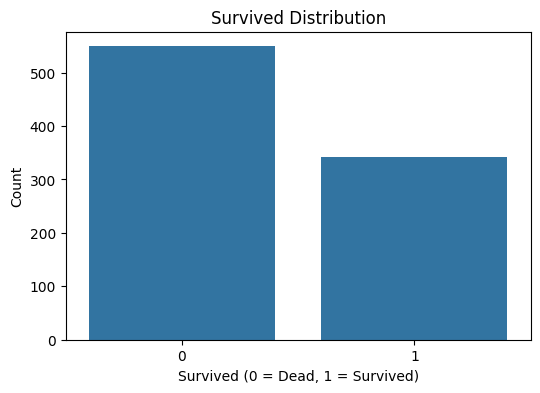

Survived
0    549
1    342
Name: count, dtype: int64
Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


In [87]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Survived")
plt.title("Survived Distribution")
plt.xlabel("Survived (0 = Dead, 1 = Survived)")
plt.ylabel("Count")
plt.show()

print(df["Survived"].value_counts())
print(df["Survived"].value_counts(normalize=True) * 100)

### 4-2. Age 변수 분포 확인

승객 나이의 분포를 히스토그램으로 확인한다.  
Age 변수는 결측치가 존재하므로 이후 결측치 대체가 필요하다.

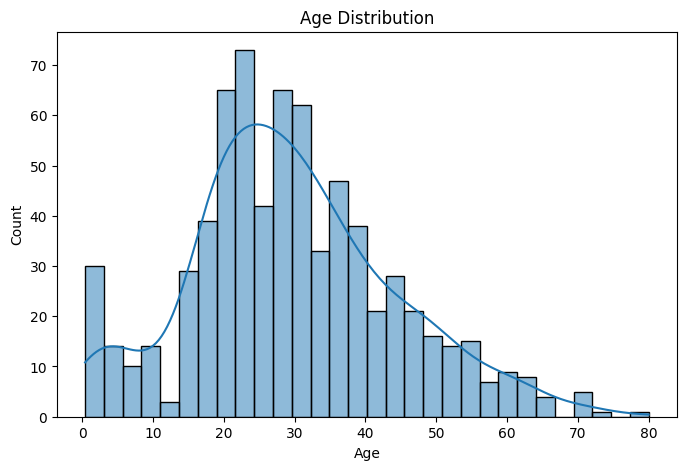

In [88]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Age", bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

### 4-3. Fare 변수 이상치 확인

운임을 나타내는 `Fare` 변수의 이상치 가능성을 박스플롯으로 확인한다.  
Fare 변수는 일부 매우 높은 값이 존재하므로 스케일링 전략이 필요하다.

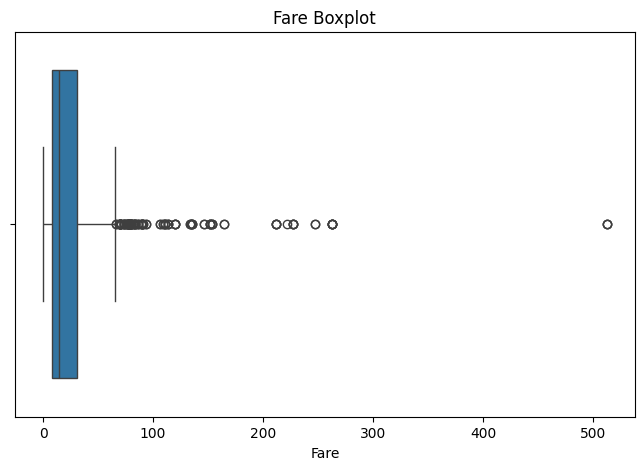

In [89]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Fare")
plt.title("Fare Boxplot")
plt.xlabel("Fare")
plt.show()

### 4-4. 수치형 변수 상관관계 분석

수치형 변수 간 상관관계를 Heatmap으로 확인한다.  
이를 통해 생존 여부와 관련성이 있는 변수를 탐색한다.

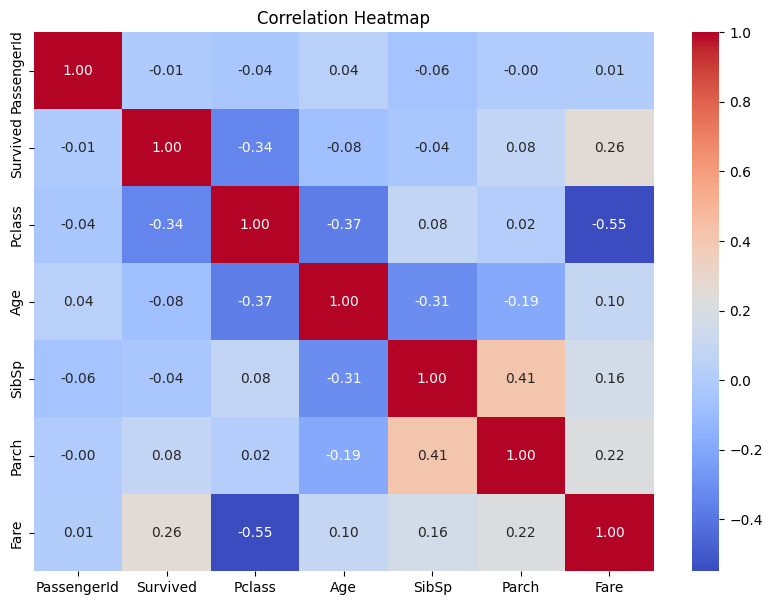

In [90]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10, 7))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### 4-5. 성별에 따른 생존 분포 확인

성별에 따라 생존 여부가 어떻게 달라지는지 확인한다.  
`Sex` 변수는 생존 예측에 중요한 범주형 변수로 활용될 수 있다.

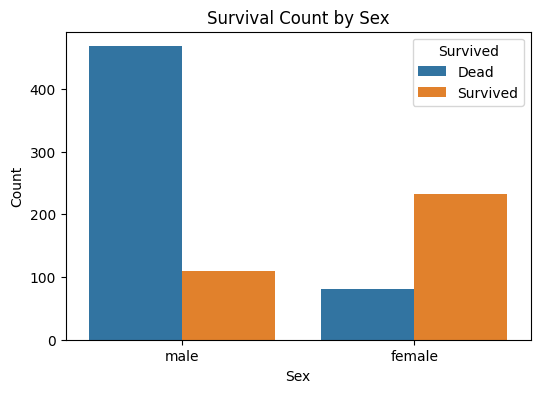

In [91]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Sex", hue="Survived")
plt.title("Survival Count by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.legend(title="Survived", labels=["Dead", "Survived"])
plt.show()

### 4-6. 객실 등급에 따른 생존 분포 확인

객실 등급별 생존 분포를 확인한다.  
`Pclass` 변수는 승객의 사회경제적 위치를 간접적으로 반영할 수 있다.

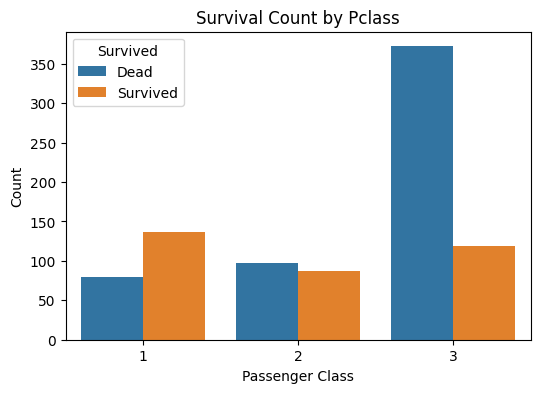

In [92]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Pclass", hue="Survived")
plt.title("Survival Count by Pclass")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.legend(title="Survived", labels=["Dead", "Survived"])
plt.show()

## 5. 파생변수 생성

원본 변수만으로는 승객의 가족 동반 여부나 개인별 운임 부담 정도를 직접적으로 파악하기 어렵다.  
따라서 `FamilySize`, `IsAlone`, `FarePerPerson`, `AgeGroup` 파생변수를 생성하여 모델 입력 정보의 표현력을 높인다.

In [93]:
# 원본 데이터 보존을 위해 복사본 생성
df_fe = df.copy()

# 1. 가족 수 = 형제/배우자 수 + 부모/자녀 수 + 자기 자신
df_fe["FamilySize"] = df_fe["SibSp"] + df_fe["Parch"] + 1

# 2. 혼자 탑승 여부
df_fe["IsAlone"] = (df_fe["FamilySize"] == 1).astype(int)

# 3. 1인당 운임
df_fe["FarePerPerson"] = df_fe["Fare"] / df_fe["FamilySize"]

# 4. 나이 구간
df_fe["AgeGroup"] = pd.cut(
    df_fe["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teen", "YoungAdult", "Adult", "Senior"]
)

df_fe[["SibSp", "Parch", "FamilySize", "IsAlone", "Fare", "FarePerPerson", "Age", "AgeGroup"]].head(10)

,SibSp,Parch,FamilySize,IsAlone,Fare,FarePerPerson,Age,AgeGroup
0,1,0,2,0,7.2500,3.62500,22.0,YoungAdult
1,1,0,2,0,71.2833,35.64165,38.0,Adult
2,0,0,1,1,7.9250,7.92500,26.0,YoungAdult
3,1,0,2,0,53.1000,26.55000,35.0,YoungAdult
4,0,0,1,1,8.0500,8.05000,35.0,YoungAdult
5,0,0,1,1,8.4583,8.45830,NaN,NaN
6,0,0,1,1,51.8625,51.86250,54.0,Adult
7,3,1,5,0,21.0750,4.21500,2.0,Child
8,0,2,3,0,11.1333,3.71110,27.0,YoungAdult
9,1,0,2,0,30.0708,15.03540,14.0,Teen


### 5-1. 파생변수와 생존 여부 관계 확인

새로 생성한 파생변수들이 생존 여부와 어떤 관계를 가지는지 시각적으로 확인한다.

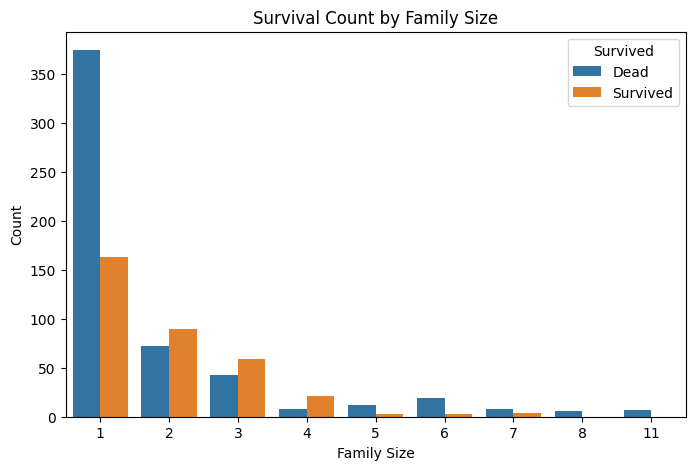

In [94]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_fe, x="FamilySize", hue="Survived")
plt.title("Survival Count by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Count")
plt.legend(title="Survived", labels=["Dead", "Survived"])
plt.show()

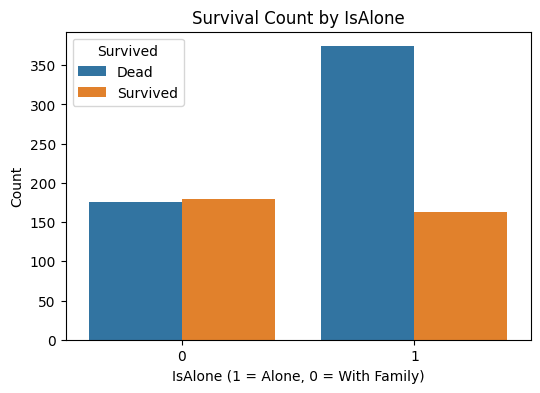

In [95]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_fe, x="IsAlone", hue="Survived")
plt.title("Survival Count by IsAlone")
plt.xlabel("IsAlone (1 = Alone, 0 = With Family)")
plt.ylabel("Count")
plt.legend(title="Survived", labels=["Dead", "Survived"])
plt.show()

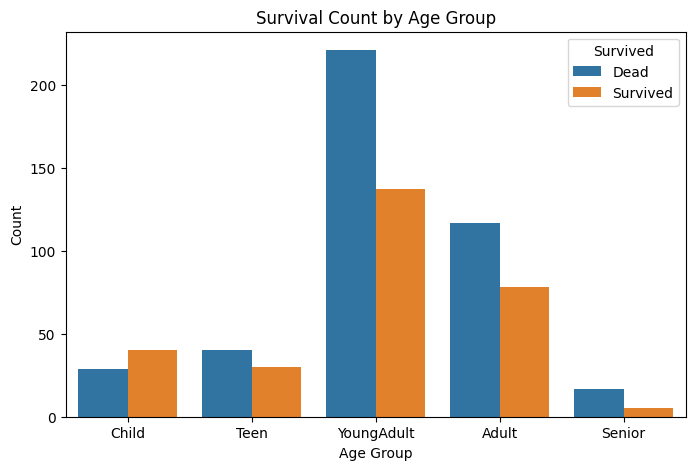

In [96]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_fe, x="AgeGroup", hue="Survived")
plt.title("Survival Count by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.legend(title="Survived", labels=["Dead", "Survived"])
plt.show()

## 6. 학습 데이터 구성

모델 학습에 사용할 입력 변수와 타겟 변수를 분리한다.  
식별자나 결측치가 많은 변수는 제외하고, 분석에 적합한 변수들을 선택한다.

In [97]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone",
    "FarePerPerson",
    "AgeGroup"
]

target = "Survived"

X = df_fe[features]
y = df_fe[target]

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

X shape: (891, 11)
y shape: (891,)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,FarePerPerson,AgeGroup
0,3,male,22.0,1,0,7.2500,S,2,0,3.62500,YoungAdult
1,1,female,38.0,1,0,71.2833,C,2,0,35.64165,Adult
2,3,female,26.0,0,0,7.9250,S,1,1,7.92500,YoungAdult
3,1,female,35.0,1,0,53.1000,S,2,0,26.55000,YoungAdult
4,3,male,35.0,0,0,8.0500,S,1,1,8.05000,YoungAdult


### 6-1. 학습 데이터와 검증 데이터 분리

전체 데이터를 학습용 데이터와 검증용 데이터로 나눈다.  
검증 데이터는 모델 성능을 평가하는 데 사용한다.

In [98]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)

X_train: (712, 11)
X_valid: (179, 11)
y_train: (712,)
y_valid: (179,)


## 7. 전처리 파이프라인 구성

결측치 처리, 범주형 인코딩, 스케일링 전략을 조합하여 여러 실험 파이프라인을 구성한다.  
Base, Exp-1, Exp-2, Exp-3 실험을 통해 전처리 방식에 따른 모델 성능 차이를 비교한다.

In [99]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [100]:
numeric_features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize",
    "IsAlone",
    "FarePerPerson"
]

categorical_features = [
    "Sex",
    "Embarked",
    "AgeGroup"
]

print("수치형 변수:", numeric_features)
print("범주형 변수:", categorical_features)

수치형 변수: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'FarePerPerson']
범주형 변수: ['Sex', 'Embarked', 'AgeGroup']


In [101]:
def evaluate_model(exp_name, model_name, pipeline, X_train, X_valid, y_train, y_valid):
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_valid)
    
    if hasattr(pipeline, "predict_proba"):
        y_proba = pipeline.predict_proba(X_valid)[:, 1]
        roc_auc = roc_auc_score(y_valid, y_proba)
    else:
        roc_auc = None
    
    result = {
        "Experiment": exp_name,
        "Model": model_name,
        "Accuracy": accuracy_score(y_valid, y_pred),
        "Precision": precision_score(y_valid, y_pred),
        "Recall": recall_score(y_valid, y_pred),
        "F1-score": f1_score(y_valid, y_pred),
        "ROC-AUC": roc_auc
    }
    
    return result

### 7-1. Base 실험

Base 실험은 최소한의 전처리만 적용한 기준 모델이다.  
문자열 변수와 결측치가 많은 변수는 제외하고, 수치형 변수 중심으로 모델을 학습한다.

In [102]:
base_numeric_features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

base_preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), base_numeric_features)
    ],
    remainder="drop"
)

base_logistic = Pipeline(steps=[
    ("preprocessor", base_preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

base_rf = Pipeline(steps=[
    ("preprocessor", base_preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

### 7-2. Exp-1: Mean Imputation + One-Hot Encoding + StandardScaler

Exp-1은 수치형 변수의 결측치를 평균값으로 대체하고, 범주형 변수는 One-Hot Encoding을 적용한다.  
수치형 변수에는 StandardScaler를 적용하여 평균 0, 표준편차 1 기준으로 변환한다.

In [103]:
exp1_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="mean")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ]
)

exp1_logistic = Pipeline(steps=[
    ("preprocessor", exp1_preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

exp1_rf = Pipeline(steps=[
    ("preprocessor", exp1_preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

### 7-3. Exp-2: Median Imputation + Ordinal Encoding + MinMaxScaler

Exp-2는 수치형 변수의 결측치를 중앙값으로 대체하고, 범주형 변수는 Ordinal Encoding 방식으로 변환한다.  
수치형 변수에는 MinMaxScaler를 적용하여 0과 1 사이의 범위로 변환한다.

In [104]:
exp2_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", MinMaxScaler())
        ]), numeric_features),
        
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
        ]), categorical_features)
    ]
)

exp2_logistic = Pipeline(steps=[
    ("preprocessor", exp2_preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

exp2_rf = Pipeline(steps=[
    ("preprocessor", exp2_preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

### 7-4. Exp-3: Most Frequent Imputation + One-Hot Encoding + RobustScaler

Exp-3은 결측치를 최빈값으로 대체하고, 범주형 변수에는 One-Hot Encoding을 적용한다.  
수치형 변수에는 이상치에 상대적으로 강한 RobustScaler를 적용한다.

In [105]:
exp3_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("scaler", RobustScaler())
        ]), numeric_features),
        
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ]
)

exp3_logistic = Pipeline(steps=[
    ("preprocessor", exp3_preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

exp3_rf = Pipeline(steps=[
    ("preprocessor", exp3_preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

### 8-1. 실험 조합별 성능 비교

Base, Exp-1, Exp-2, Exp-3 실험을 각각 Logistic Regression과 Random Forest 모델에 적용하여 성능을 비교한다.

In [106]:
results = []

experiments = [
    ("Base", "Logistic Regression", base_logistic),
    ("Base", "Random Forest", base_rf),
    ("Exp-1", "Logistic Regression", exp1_logistic),
    ("Exp-1", "Random Forest", exp1_rf),
    ("Exp-2", "Logistic Regression", exp2_logistic),
    ("Exp-2", "Random Forest", exp2_rf),
    ("Exp-3", "Logistic Regression", exp3_logistic),
    ("Exp-3", "Random Forest", exp3_rf),
]

for exp_name, model_name, pipeline in experiments:
    result = evaluate_model(
        exp_name,
        model_name,
        pipeline,
        X_train,
        X_valid,
        y_train,
        y_valid
    )
    results.append(result)

results_df = pd.DataFrame(results)
results_df

,Experiment,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Base,Logistic Regression,0.675978,0.622222,0.405797,0.491228,0.703491
1,Base,Random Forest,0.592179,0.471429,0.478261,0.474820,0.641238
2,Exp-1,Logistic Regression,0.826816,0.827586,0.695652,0.755906,0.859420
3,Exp-1,Random Forest,0.793296,0.735294,0.724638,0.729927,0.818511
4,Exp-2,Logistic Regression,0.798883,0.770492,0.681159,0.723077,0.849407
5,Exp-2,Random Forest,0.810056,0.761194,0.739130,0.750000,0.825494
6,Exp-3,Logistic Regression,0.821229,0.813559,0.695652,0.750000,0.860079
7,Exp-3,Random Forest,0.810056,0.761194,0.739130,0.750000,0.815810


In [107]:
results_df_round = results_df.copy()

score_cols = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
results_df_round[score_cols] = results_df_round[score_cols].round(4)

results_df_round

,Experiment,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Base,Logistic Regression,0.6760,0.6222,0.4058,0.4912,0.7035
1,Base,Random Forest,0.5922,0.4714,0.4783,0.4748,0.6412
2,Exp-1,Logistic Regression,0.8268,0.8276,0.6957,0.7559,0.8594
3,Exp-1,Random Forest,0.7933,0.7353,0.7246,0.7299,0.8185
4,Exp-2,Logistic Regression,0.7989,0.7705,0.6812,0.7231,0.8494
5,Exp-2,Random Forest,0.8101,0.7612,0.7391,0.7500,0.8255
6,Exp-3,Logistic Regression,0.8212,0.8136,0.6957,0.7500,0.8601
7,Exp-3,Random Forest,0.8101,0.7612,0.7391,0.7500,0.8158


### 8-1. 실험 조합별 성능 비교

Base, Exp-1, Exp-2, Exp-3 실험을 각각 Logistic Regression과 Random Forest 모델에 적용하여 성능을 비교한다.

In [108]:
# Exp-1 전처리기를 기준으로 학습 데이터 전처리
exp1_preprocessor.fit(X_train)

X_train_exp1 = exp1_preprocessor.transform(X_train)
X_valid_exp1 = exp1_preprocessor.transform(X_valid)

print("전처리 후 X_train shape:", X_train_exp1.shape)
print("전처리 후 X_valid shape:", X_valid_exp1.shape)

전처리 후 X_train shape: (712, 18)
전처리 후 X_valid shape: (179, 18)


In [109]:
# 수치형 변수 이름
num_feature_names = numeric_features

# 범주형 변수 One-Hot Encoding 이후 이름 가져오기
cat_feature_names = exp1_preprocessor.named_transformers_["cat"] \
    .named_steps["encoder"] \
    .get_feature_names_out(categorical_features)

# 전체 변수 이름 합치기
all_feature_names = list(num_feature_names) + list(cat_feature_names)

print("전체 변수 개수:", len(all_feature_names))
print(all_feature_names)

전체 변수 개수: 18
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'FarePerPerson', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'AgeGroup_Adult', 'AgeGroup_Child', 'AgeGroup_Senior', 'AgeGroup_Teen', 'AgeGroup_YoungAdult']


### 9-1. Random Forest 기반 변수 중요도 계산

Random Forest 모델을 활용하여 각 변수의 중요도를 계산하고, 생존 예측에 영향을 많이 준 상위 변수를 확인한다.

In [110]:
rf_for_importance = RandomForestClassifier(random_state=42)
rf_for_importance.fit(X_train_exp1, y_train)

feature_importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": rf_for_importance.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df

,Feature,Importance
1,Age,0.171503
7,FarePerPerson,0.162450
4,Fare,0.152557
8,Sex_female,0.142957
9,Sex_male,0.133644
0,Pclass,0.061106
5,FamilySize,0.041198
2,SibSp,0.023676
3,Parch,0.017709
14,AgeGroup_Child,0.017595


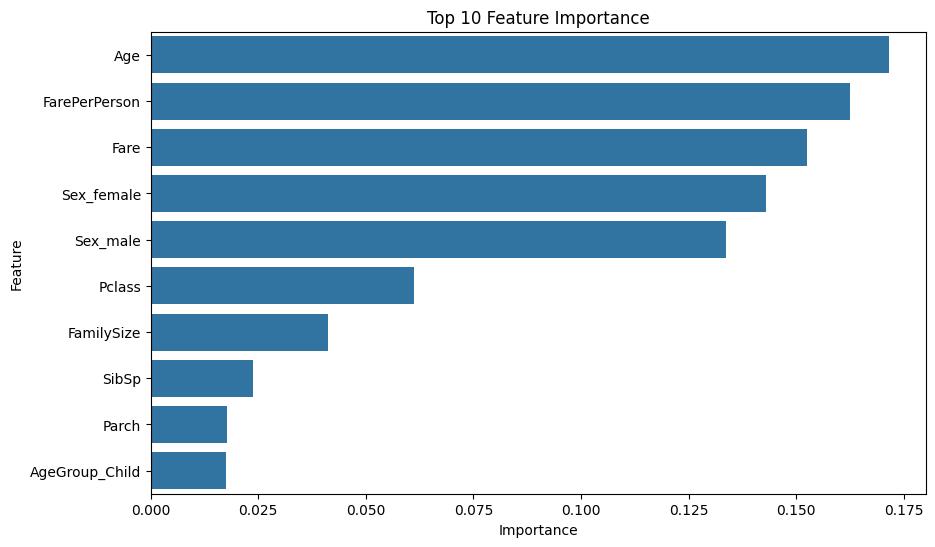

In [111]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_df.head(10),
    x="Importance",
    y="Feature"
)
plt.title("Top 10 Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [112]:
top_n = 8

top_features = feature_importance_df.head(top_n)["Feature"].tolist()

print("선택된 상위 변수:")
print(top_features)

선택된 상위 변수:
['Age', 'FarePerPerson', 'Fare', 'Sex_female', 'Sex_male', 'Pclass', 'FamilySize', 'SibSp']


In [113]:
# 전처리된 데이터를 DataFrame으로 변환
X_train_exp1_df = pd.DataFrame(X_train_exp1, columns=all_feature_names)
X_valid_exp1_df = pd.DataFrame(X_valid_exp1, columns=all_feature_names)

# 상위 변수만 선택
X_train_selected = X_train_exp1_df[top_features]
X_valid_selected = X_valid_exp1_df[top_features]

print("Feature Selection 전:", X_train_exp1_df.shape)
print("Feature Selection 후:", X_train_selected.shape)

Feature Selection 전: (712, 18)
Feature Selection 후: (712, 8)


### 9-2. Feature Selection 적용 후 성능 평가

중요도 상위 8개 변수만 사용하여 모델을 다시 학습하고, 전체 변수를 사용했을 때와 성능을 비교한다.

In [114]:
fs_results = []

models = [
    ("Logistic Regression", LogisticRegression(max_iter=1000)),
    ("Random Forest", RandomForestClassifier(random_state=42))
]

for model_name, model in models:
    model.fit(X_train_selected, y_train)
    y_pred = model.predict(X_valid_selected)
    y_proba = model.predict_proba(X_valid_selected)[:, 1]
    
    fs_results.append({
        "Experiment": "Exp-1 + Feature Selection",
        "Model": model_name,
        "Selected Features": top_n,
        "Accuracy": accuracy_score(y_valid, y_pred),
        "Precision": precision_score(y_valid, y_pred),
        "Recall": recall_score(y_valid, y_pred),
        "F1-score": f1_score(y_valid, y_pred),
        "ROC-AUC": roc_auc_score(y_valid, y_proba)
    })

fs_results_df = pd.DataFrame(fs_results)

score_cols = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
fs_results_df[score_cols] = fs_results_df[score_cols].round(4)

fs_results_df

,Experiment,Model,Selected Features,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Exp-1 + Feature Selection,Logistic Regression,8,0.8156,0.8000,0.6957,0.7442,0.8536
1,Exp-1 + Feature Selection,Random Forest,8,0.7877,0.7246,0.7246,0.7246,0.8273


In [115]:
before_fs = results_df_round[results_df_round["Experiment"] == "Exp-1"].copy()
before_fs["Selected Features"] = "All"

after_fs = fs_results_df.copy()

fs_compare_df = pd.concat([before_fs, after_fs], ignore_index=True)

fs_compare_df

,Experiment,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,Selected Features
0,Exp-1,Logistic Regression,0.8268,0.8276,0.6957,0.7559,0.8594,All
1,Exp-1,Random Forest,0.7933,0.7353,0.7246,0.7299,0.8185,All
2,Exp-1 + Feature Selection,Logistic Regression,0.8156,0.8000,0.6957,0.7442,0.8536,8
3,Exp-1 + Feature Selection,Random Forest,0.7877,0.7246,0.7246,0.7246,0.8273,8


In [116]:
# 전체 실험 결과표 확인
results_df_round

,Experiment,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Base,Logistic Regression,0.6760,0.6222,0.4058,0.4912,0.7035
1,Base,Random Forest,0.5922,0.4714,0.4783,0.4748,0.6412
2,Exp-1,Logistic Regression,0.8268,0.8276,0.6957,0.7559,0.8594
3,Exp-1,Random Forest,0.7933,0.7353,0.7246,0.7299,0.8185
4,Exp-2,Logistic Regression,0.7989,0.7705,0.6812,0.7231,0.8494
5,Exp-2,Random Forest,0.8101,0.7612,0.7391,0.7500,0.8255
6,Exp-3,Logistic Regression,0.8212,0.8136,0.6957,0.7500,0.8601
7,Exp-3,Random Forest,0.8101,0.7612,0.7391,0.7500,0.8158


In [117]:
# Feature Selection 전/후 비교표 확인
fs_compare_df

,Experiment,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,Selected Features
0,Exp-1,Logistic Regression,0.8268,0.8276,0.6957,0.7559,0.8594,All
1,Exp-1,Random Forest,0.7933,0.7353,0.7246,0.7299,0.8185,All
2,Exp-1 + Feature Selection,Logistic Regression,0.8156,0.8000,0.6957,0.7442,0.8536,8
3,Exp-1 + Feature Selection,Random Forest,0.7877,0.7246,0.7246,0.7246,0.8273,8


## 10. 최종 결과 시각화

전체 실험 결과를 그래프로 시각화하여 전처리 조합별 모델 성능 차이를 비교한다.

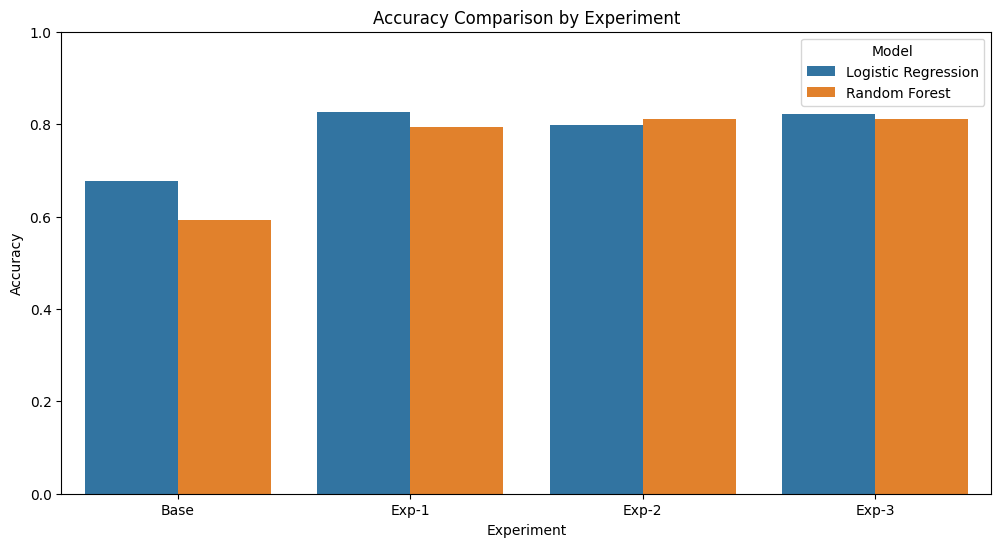

In [118]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=results_df_round,
    x="Experiment",
    y="Accuracy",
    hue="Model"
)
plt.title("Accuracy Comparison by Experiment")
plt.xlabel("Experiment")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.legend(title="Model")
plt.show()

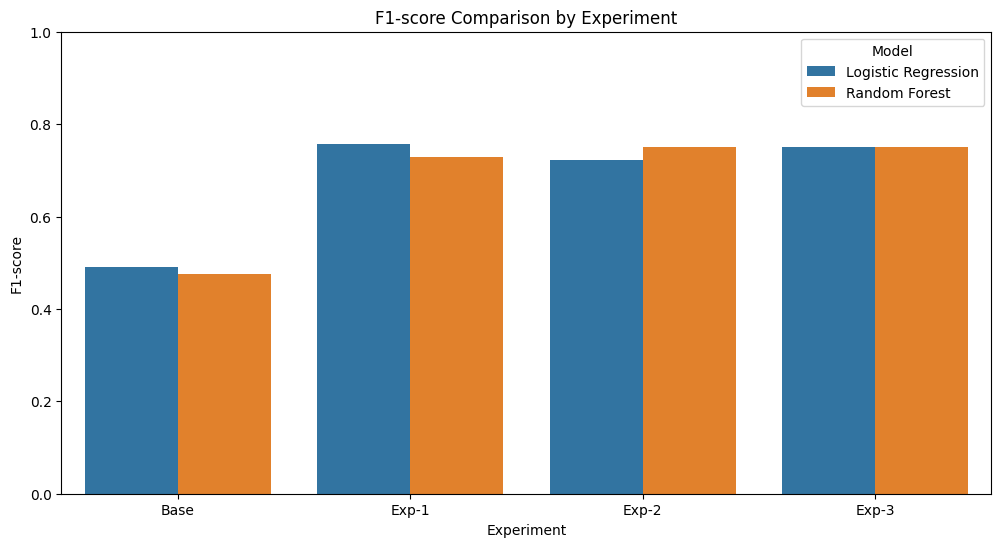

In [119]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=results_df_round,
    x="Experiment",
    y="F1-score",
    hue="Model"
)
plt.title("F1-score Comparison by Experiment")
plt.xlabel("Experiment")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.legend(title="Model")
plt.show()

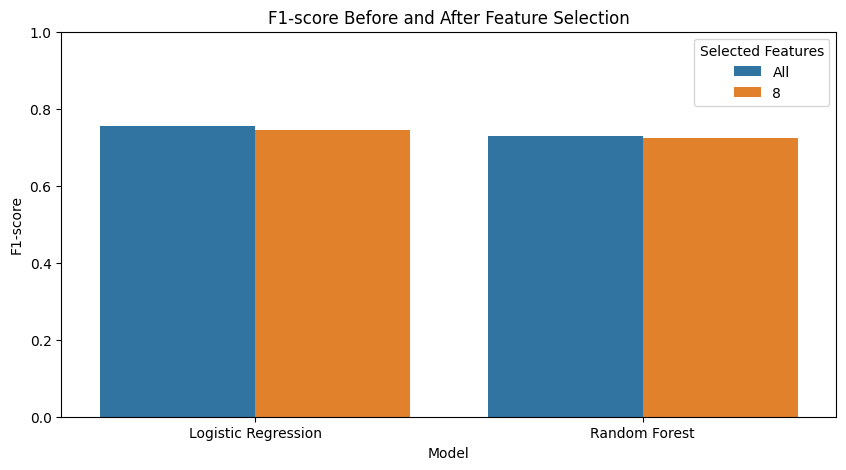

In [120]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=fs_compare_df,
    x="Model",
    y="F1-score",
    hue="Selected Features"
)
plt.title("F1-score Before and After Feature Selection")
plt.xlabel("Model")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.legend(title="Selected Features")
plt.show()

## 11. 결과 파일 저장

전체 실험 결과와 Feature Selection 전후 비교 결과를 CSV 파일로 저장한다.  
저장된 결과 파일은 PDF 보고서 작성에 활용한다.

In [121]:
results_df_round.to_csv("experiment_results.csv", index=False, encoding="utf-8-sig")
fs_compare_df.to_csv("feature_selection_results.csv", index=False, encoding="utf-8-sig")